In [1]:
import pandas as pd

# carrega a tabela de pedidos
pedidos = pd.read_csv("../data/olist_orders_dataset.csv")
pedidos.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [2]:
print(pedidos.shape)
pedidos.info()

(99441, 8)
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [3]:
colunas_data = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in colunas_data:
    pedidos[col] = pd.to_datetime(pedidos[col])

pedidos.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [4]:
pedidos["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [5]:
sem_entrega = pedidos[pedidos["order_delivered_customer_date"].isna()]
sem_entrega["order_status"].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

## Valores faltando na tabela de pedidos

Percebi que, dentre as colunas de data, três têm valores vazios. A coluna "order_delivered_customer_date" apresenta 2.965 valores nulos e quase todos eles fazem sentido: são pedidos cancelados, em transporte ou ainda em processamento, então não devem mesmo ter data de entrega definida. No entanto, encontrei 8 pedidos com status "delivered" que não possuem data, o que configura uma inconsistência, já que pedidos marcados como entregues devem ter data de entrega definida. Como são poucos, decidi deixá-los de fora da análise de atraso.

In [6]:
entregues = pedidos[
    (pedidos["order_status"] == "delivered")
    & (pedidos["order_delivered_customer_date"].notna())
].copy()
entregues.shape

(96470, 8)

In [7]:
entregues["dias_atraso"] = (
    entregues["order_delivered_customer_date"]
    - entregues["order_estimated_delivery_date"]
).dt.days

entregues["dias_atraso"].describe()

count    96470.000000
mean       -11.875889
std         10.182105
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: dias_atraso, dtype: float64

In [8]:
atrasados = entregues[entregues["dias_atraso"] > 0]
print(len(atrasados))
print(len(atrasados) / len(entregues) * 100)

6534
6.7730900798175595


In [9]:
avaliacoes = pd.read_csv("../data/olist_order_reviews_dataset.csv")
avaliacoes.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [10]:
print(avaliacoes.shape)
avaliacoes.info()

(99224, 7)
<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [11]:
avaliacoes["order_id"].nunique()

98673

In [12]:
avaliacoes["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [13]:
contagem = avaliacoes["order_id"].value_counts()
repetidos = contagem[contagem > 1]
print(len(repetidos))
repetidos.head()

547


order_id
c88b1d1b157a9999ce368f218a407141    3
df56136b8031ecd28e200bb18e6ddb2e    3
03c939fd7fd3b38f8485a0f95798f1f6    3
8e17072ec97ce29f0e1f111e598b0c85    3
cf73e2cb1f4a9480ed70c154da3d954a    2
Name: count, dtype: int64

In [14]:
exemplo = repetidos.index[0]
avaliacoes[avaliacoes["order_id"] == exemplo]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
1985,ffb8cff872a625632ac983eb1f88843c,c88b1d1b157a9999ce368f218a407141,3,NaN,NaN,2017-07-22 00:00:00,2017-07-26 13:41:07
82525,202b5f44d09cd3cfc0d6bd12f01b044c,c88b1d1b157a9999ce368f218a407141,5,NaN,NaN,2017-07-22 00:00:00,2017-07-26 13:40:22
89360,fb96ea2ef8cce1c888f4d45c8e22b793,c88b1d1b157a9999ce368f218a407141,5,NaN,NaN,2017-07-21 00:00:00,2017-07-26 13:45:15


In [15]:
repetidas = avaliacoes[avaliacoes["order_id"].isin(repetidos.index)]
notas_distintas = repetidas.groupby("order_id")["review_score"].nunique()
(notas_distintas > 1).sum()

np.int64(202)

In [16]:
avaliacoes["review_answer_timestamp"] = pd.to_datetime(avaliacoes["review_answer_timestamp"])

In [17]:
avaliacoes_unicas = (
    avaliacoes
    .sort_values("review_answer_timestamp")
    .drop_duplicates(subset="order_id", keep="last")
)
print(avaliacoes_unicas.shape)
avaliacoes_unicas["order_id"].nunique()

(98673, 7)


98673

In [18]:
base = entregues.merge(
    avaliacoes_unicas[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)
print(base.shape)
print(len(entregues) - len(base))

(95824, 10)
646


In [19]:
base["atrasado"] = base["dias_atraso"] > 0

base.groupby("atrasado")["review_score"].agg(["count", "mean"])

,count,mean
atrasado,,
False,89443,4.290386
True,6381,2.270491


In [20]:
faixas = pd.cut(
    base["dias_atraso"],
    bins=[-200, 0, 3, 7, 15, 200],
    labels=["no prazo", "1 a 3 dias", "4 a 7 dias", "8 a 15 dias", "mais de 15 dias"]
)

base.groupby(faixas, observed=True)["review_score"].agg(["count", "mean"])

,count,mean
dias_atraso,,
no prazo,89443,4.290386
1 a 3 dias,1852,3.291037
4 a 7 dias,1748,2.102975
8 a 15 dias,1601,1.673954
mais de 15 dias,1180,1.726271


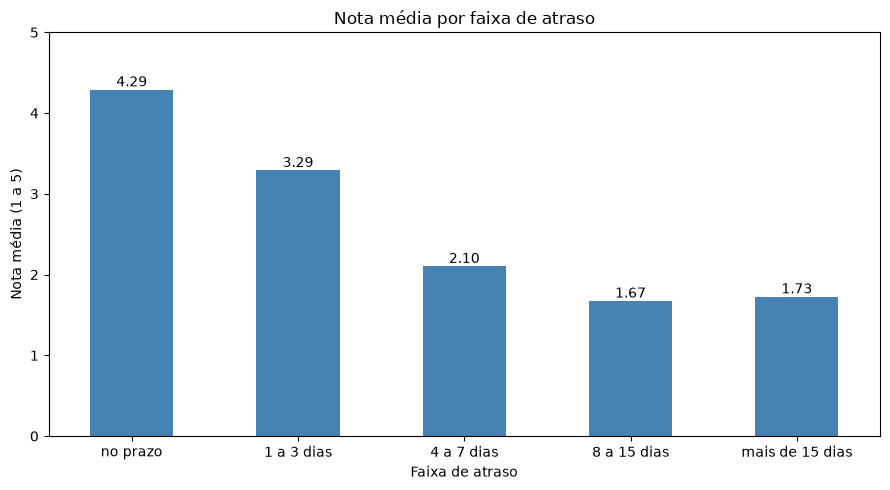

In [22]:
import matplotlib.pyplot as plt

media_por_faixa = base.groupby(faixas, observed=True)["review_score"].mean()

ax = media_por_faixa.plot(kind="bar", color="steelblue", figsize=(9, 5))
ax.bar_label(ax.containers[0], fmt="%.2f")
plt.title("Nota média por faixa de atraso")
plt.xlabel("Faixa de atraso")
plt.ylabel("Nota média (1 a 5)")
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig("../images/nota_por_atraso.png", dpi=150)
plt.show()

## Atraso na entrega e nota de avaliação

Dos 95.824 pedidos entregues que têm avaliação, 6.381 (cerca de 6,7%) chegaram depois do prazo estimado. A nota média desses pedidos foi de 2,27, contra 4,29 dos pedidos que chegaram no prazo. Ou seja, quem recebeu atrasado avaliou, em média, pouco mais de dois pontos abaixo.

Dividindo os atrasos em faixas, percebi que a maior queda acontece na primeira semana: a nota vai de 4,29 no prazo para 3,29 com 1 a 3 dias de atraso, e então desce novamente para 2,10 com 4 a 7 dias; a partir de 8 dias após o fim do prazo ela praticamente para de cair e fica perto de 1,7. Isso mostra que atraso e nota baixa andam juntos, mas não prova que o atraso é a única causa, uma vez que um pedido atrasado pode ter tido outros problemas também.

Para chegar nesses números, usei somente os pedidos entregues com avaliação, e nos 547 pedidos com mais de uma avaliação, fiquei com a mais recente, considerando que a última representa a decisão final do cliente.